# 00 Read, subset, reproject, export

An ER Mapper grid is a text header (`.ers`) plus a flat binary file of the
same name. GDAL reads it, so `read_grid` takes any raster GDAL knows: ERS,
GeoTIFF, Surfer GRD, Arc ASCII, netCDF.

`Grid` conventions: row 0 is the north edge, column 0 the west edge, null
cells are NaN, `values` is float64. Coordinates come from an affine
transform and a CRS.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from potfield import read_grid, write_grid, filters, transforms, spectrum, display

DATA = "../data"
OUT = "../outputs"
INC, DEC = -62.4, 7.5   # IGRF inclination, declination (deg) for the Frome area at 2015.0
plt.rcParams["figure.dpi"] = 90

In [2]:
print(open(f"{DATA}/frome_tmi.ers").read())

DatasetHeader Begin
	Version	= "6.0"
	Name	= "frome_tmi.ers"
	DataSetType	= ERStorage
	DataType	= Raster
	ByteOrder	= LSBFirst
	CoordinateSpace Begin
		Datum	= "GDA94"
		Projection	= "GEODETIC"
		CoordinateType	= LATLONG
		Rotation	= 0:0:0.0
	CoordinateSpace End
	RasterInfo Begin
		CellType	= IEEE4ByteReal
		NullCellValue	= -99999
		CellInfo Begin
			Xdimension	= 0.000833333
			Ydimension	= 0.000833333
		CellInfo End
		NrOfLines	= 1680
		NrOfCellsPerLine	= 1668
		NrOfBands	= 1
		RegistrationCellX	= 0
		RegistrationCellY	= 0
		RegistrationCoord Begin
			Longitude	= 139:0:36.077423
			Latitude	= -29:47:59.351487
		RegistrationCoord End
		BandId Begin
			Value	= "nT"
		BandId End
	RasterInfo End
DatasetHeader End



In [3]:
tmi = read_grid(f"{DATA}/frome_tmi.ers", units="nT")
print(tmi)
tmi.stats()

Grid('frome_tmi', 1680x1668, cell 0.000833333x0.000833333 deg (~80x93 m), EPSG:None, bounds W139.0100 S-31.1998 E140.4000 N-29.7998, units 'nT')


{'n': 2802240,
 'null': 0,
 'min': -690.1635131835938,
 'max': 7693.84765625,
 'mean': 268.9469645007088,
 'std': 242.94321731800616}

The grid is in degrees. At 30 S one degree of longitude is 96 km and one of
latitude 111 km, so the cells are 80 x 93 m on the ground. `spacing()`
reports that approximation. Filters need metres, so the usual first step is
to warp onto a projected grid. The default target is the MGA zone under the
grid centre (GDA94, EPSG 28349 to 28356). Pass `epsg=` for anything else,
for example EPSG 7854 for GDA2020 zone 54.

<Axes: title={'center': 'frome_tmi'}, xlabel='Longitude (deg)', ylabel='Latitude (deg)'>

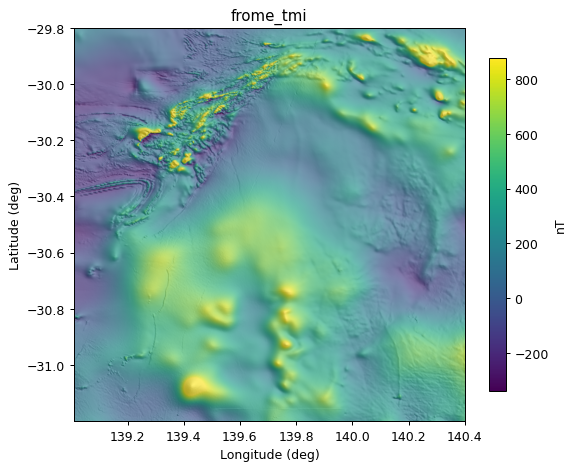

In [4]:
display.plot(tmi, cmap="viridis", clip=("std", 2.5), shade={"azimuth": 45, "altitude": 45})

## Subset

`bounds` are `(west, south, east, north)`. They are taken in the grid CRS
unless `bounds_epsg` says otherwise. `read_grid(..., bounds=...)` reads only
that window from disk, which is how to work with the national grids.

In [5]:
arka = tmi.subset((139.30, -30.45, 139.75, -30.10))
print(arka)
m = arka.reproject()          # MGA zone 54
print(m)
print("spacing before (m):", [round(v) for v in arka.spacing()], " after:", [round(v) for v in m.spacing()])

Grid('frome_tmi', 421x541, cell 0.000833333x0.000833333 deg (~80x93 m), EPSG:None, bounds W139.2992 S-30.4507 E139.7500 N-30.0998, units 'nT')
Grid('frome_tmi', 464x516, cell 84.9763x84.9763 m (~85x85 m), EPSG:28354, bounds W336112.9910 S6630065.7694 E379960.7761 N6669494.7854, units 'nT')
spacing before (m): [80, 93]  after: [85, 85]


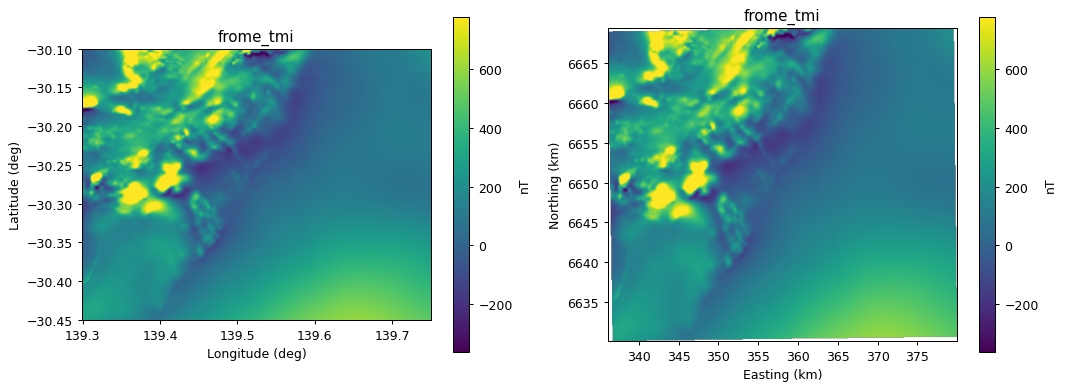

In [6]:
fig, axes = display.compare([arka, m], ncols=2, cmap="viridis", clip=("std", 2.5))

## Clip to a polygon

`clip` takes a shapely geometry in the grid CRS and sets cells outside it to
NaN. A tenement or geology polygon from a shapefile works the same way
(geopandas gives shapely geometries); here a box rotated 20 degrees shows
the effect.

{'n': 137943, 'null': 90285, 'min': -240.08840615674745, 'max': 2519.195855108589, 'mean': 156.9911257138074, 'std': 208.9754530943042}


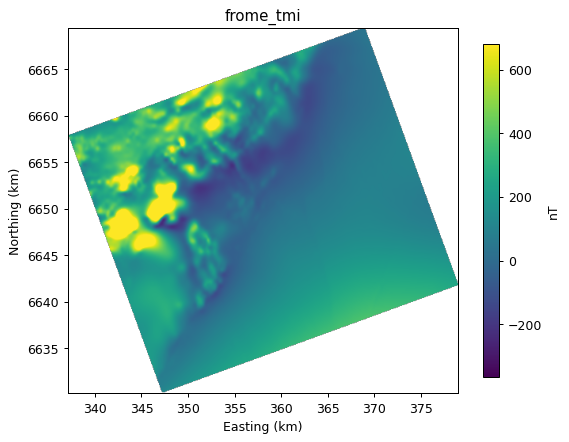

In [7]:
from shapely import affinity
from shapely.geometry import box

w, s, e, n = m.bounds
poly = affinity.rotate(box(w + 5000, s + 5000, e - 5000, n - 5000), 20)
clipped = m.clip(poly)
display.plot(clipped, clip=("std", 2.5))
print(clipped.stats())

## Export

Format follows the extension. Geotools needs the file CRS to match its
database, so pass `epsg=` and the grid is warped on the way out. Surfer
`.grd` has no CRS field; the CRS goes in a `.aux.xml` sidecar. Arc ASCII
gets a `.prj`. ERS is written with the same header layout as the GA grids.

In [8]:
import os
os.makedirs(OUT, exist_ok=True)
for ext in ("tif", "grd", "asc", "ers", "xyz", "nc"):
    print(write_grid(m, f"{OUT}/arkaroola_tmi.{ext}"))
print(write_grid(m, f"{OUT}/arkaroola_tmi_z53.grd", epsg=28353))   # e.g. a Geotools database in zone 53

..\outputs\arkaroola_tmi.tif


..\outputs\arkaroola_tmi.grd
..\outputs\arkaroola_tmi.asc
..\outputs\arkaroola_tmi.ers


..\outputs\arkaroola_tmi.xyz


..\outputs\arkaroola_tmi.nc


..\outputs\arkaroola_tmi_z53.grd


In [9]:
back = read_grid(f"{OUT}/arkaroola_tmi.grd", units="nT")
print(back)
finite = np.isfinite(m.values)
print("max abs difference after Surfer round trip:", np.max(np.abs(back.values[finite] - m.values[finite])))

Grid('arkaroola_tmi', 464x516, cell 84.9763x84.9763 m (~85x85 m), EPSG:28354, bounds W336112.9910 S6630065.7694 E379960.7761 N6669494.7854, units 'nT')
max abs difference after Surfer round trip: 0.00012200421315355925


## EPSG codes for Australian grids

Codes checked against the EPSG database through pyproj (cell below). MGA
zones are 6 degrees wide: zone 49 covers 108 to 114 E, zone 53 132 to 138 E,
zone 54 138 to 144 E, zone 56 150 to 156 E; central meridian is 6n - 183.
`Grid.mga_epsg()` picks the zone under the grid centre.

| CRS | EPSG |
|---|---|
| GDA94 geographic | 4283 |
| GDA2020 geographic | 7844 |
| WGS 84 geographic | 4326 |
| AGD66, AGD84 geographic | 4202, 4203 |
| GDA94 / MGA zones 49 to 56 | 28349 to 28356 |
| GDA2020 / MGA zones 49 to 56 | 7849 to 7856 |
| AGD66 / AMG zones 49 to 56 | 20249 to 20256 |
| AGD84 / AMG zones 49 to 56 | 20349 to 20356 |
| WGS 84 / UTM zones 49S to 56S | 32749 to 32756 |
| GDA94 / Geoscience Australia Lambert | 3112 |
| GDA2020 / GA Lambert Conformal Conic | 7845 |
| GDA94 / Australian Albers | 3577 |
| GDA2020 / Australian Albers | 9473 |
| GDA94 / SA Lambert | 3107 |
| GDA2020 / SA Lambert | 8059 |
| GDA94 / NSW Lambert | 3308 |
| GDA2020 / NSW Lambert | 8058 |
| GDA94 / Vicgrid | 3111 |
| GDA2020 / Vicgrid | 7899 |

GDA94 to GDA2020 moves coordinates by about 1.8 m; AGD66 or AGD84 to GDA94
by about 200 m. pyproj applies the datum transformation when the source and
target differ, so an old AMG-based database is handled by giving its code.
Old SA state grids label EPSG 3107 as `L2SAUST`.

In [10]:
import pyproj

codes = [4283, 7844, 4326, 4202, 4203, 28353, 28354, 7853, 7854, 20253, 20353, 32753,
         3112, 7845, 3577, 9473, 3107, 8059, 3308, 8058, 3111, 7899]
for c in codes:
    crs = pyproj.CRS.from_epsg(c)
    print(f"{c:>6}  {crs.name:45s} {crs.axis_info[0].unit_name}")
print("\nMGA zone under this grid: GDA94", m.mga_epsg(), " GDA2020", m.mga_epsg("GDA2020"))

  4283  GDA94                                         degree
  7844  GDA2020                                       degree
  4326  WGS 84                                        degree
  4202  AGD66                                         degree
  4203  AGD84                                         degree
 28353  GDA94 / MGA zone 53                           metre
 28354  GDA94 / MGA zone 54                           metre
  7853  GDA2020 / MGA zone 53                         metre
  7854  GDA2020 / MGA zone 54                         metre
 20253  AGD66 / AMG zone 53                           metre
 20353  AGD84 / AMG zone 53                           metre
 32753  WGS 84 / UTM zone 53S                         metre
  3112  GDA94 / Geoscience Australia Lambert          metre
  7845  GDA2020 / GA LCC                              metre
  3577  GDA94 / Australian Albers                     metre
  9473  GDA2020 / Australian Albers                   metre
  3107  GDA94 / SA Lambert         